In [1]:
import os.path
import warnings
import torch
import numpy as np
import joblib
from cVAE import cVAE
from tortreinador.utils.View import init_weights
from config import PlanetsDataGenerator, input_parameters, output_parameters, DEVICE
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
from tools import get_pred_mean, get_cluster_center
from sklearn.preprocessing import StandardScaler
from kmeans import get_elbow, get_mean_std, filter_by_std, get_error_bar
from sklearn.cluster import KMeans

plt.rcParams['axes.labelcolor'] = 'black'     
plt.rcParams['xtick.color']     = 'black'    
plt.rcParams['ytick.color']     = 'black'  
plt.rcParams['legend.edgecolor'] = 'white'  
plt.rcParams['legend.facecolor'] = 'white' 
plt.rcParams['text.color']      = 'black'
plt.rcParams['axes.grid'] = False

warnings.filterwarnings('ignore')

In [2]:
base_path = '.\\data'
heatmap_save_path = os.path.join(base_path, 'Charts', 'heatmap')
cluster_bar_save_path = os.path.join(base_path, 'Charts', 'Cluster_bar')
cluster_error_bar_save_path = os.path.join(base_path, 'Charts', 'Cluster_error_bar')
cvae_path = os.path.join(base_path, 'cVAE')
mdn_path = os.path.join(base_path, 'MDN')

degree_50 = os.path.join(cvae_path, '50th')

cvae_m_x_50th = joblib.load(os.path.join(degree_50, 'Xscaler.save'))
cvae_m_y_50th = joblib.load(os.path.join(degree_50, 'yscaler.save'))

sample_num = 1000
TIMES = 20

y_locator = [0.2, 0.2, 0.2, 0.5, 2, 0.5]
y_max = [1, 1, 1, 1.5, 6, 1.5]

x_labels = [
    'MRF',
    'CRF',
    'CMF',
    '$P_{\mathrm{CMB}}$(TPa)',
    '$T_{\mathrm{CMB}}(10^{3}$K$)$',
    '$k_{2}$'
]

# Model Loading

In [3]:
"""
    cVAE 
"""
cvae_model = cVAE(i_dim=len(output_parameters), z_dim=int(len(output_parameters) * 7), num_hidden=1024, c_dim=len(input_parameters), o_dim=len(output_parameters))
init_weights(cvae_model)
cvae_model.load_state_dict(torch.load(os.path.join(degree_50, "best_model.pth")))
cvae_decoder = cvae_model.decoder
cvae_encoder = cvae_model.encoder

cvae_encoder.to(DEVICE)
cvae_decoder.to(DEVICE)

Decoder(
  (fc_z1): Linear(in_features=60, out_features=2048, bias=True)
  (fc_z2): Linear(in_features=2048, out_features=2048, bias=True)
  (fc_z3): Linear(in_features=2048, out_features=1024, bias=True)
  (fc_out): Linear(in_features=1024, out_features=8, bias=True)
)

# Directing Prediction Loop

points: 100%|██████████| 1000/1000 [00:00<00:00, 2056.73it/s]


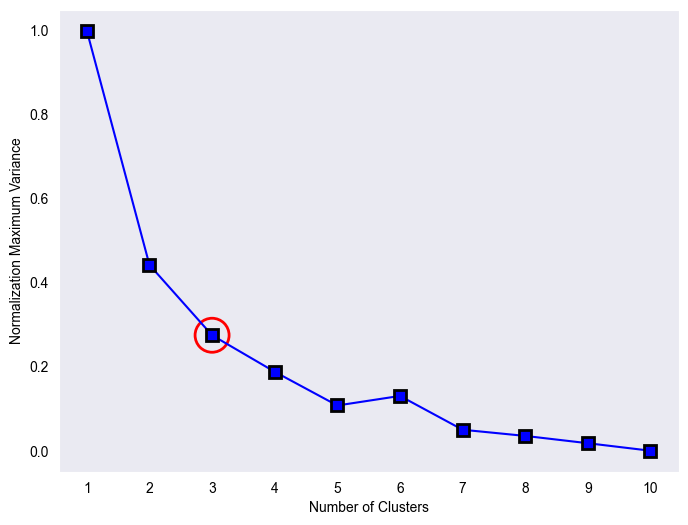

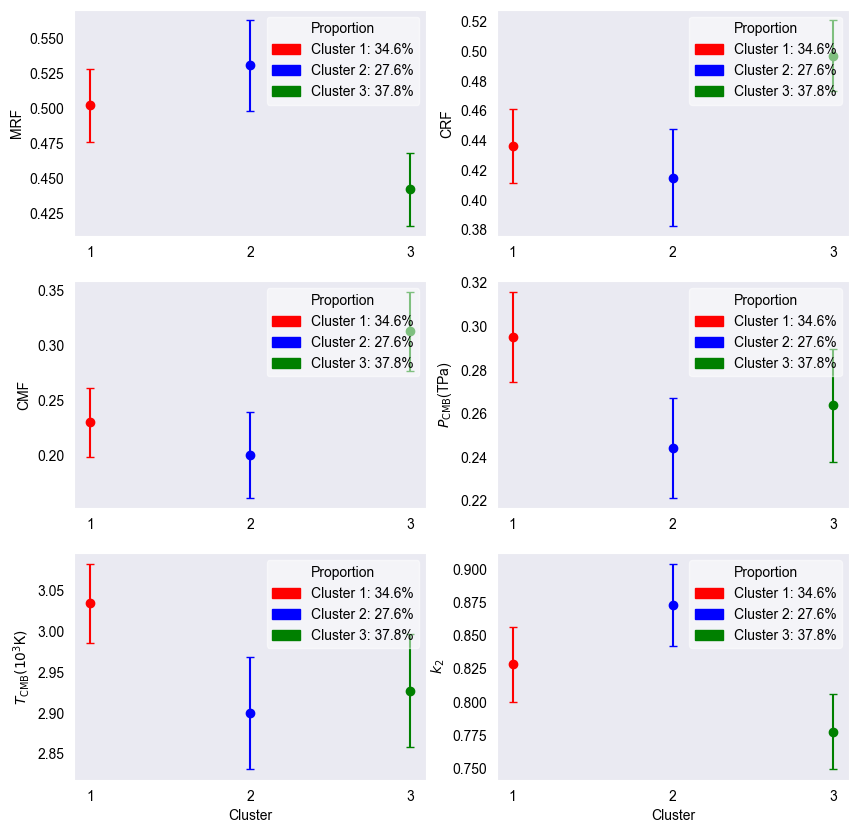

points: 100%|██████████| 1000/1000 [00:00<00:00, 4083.51it/s]


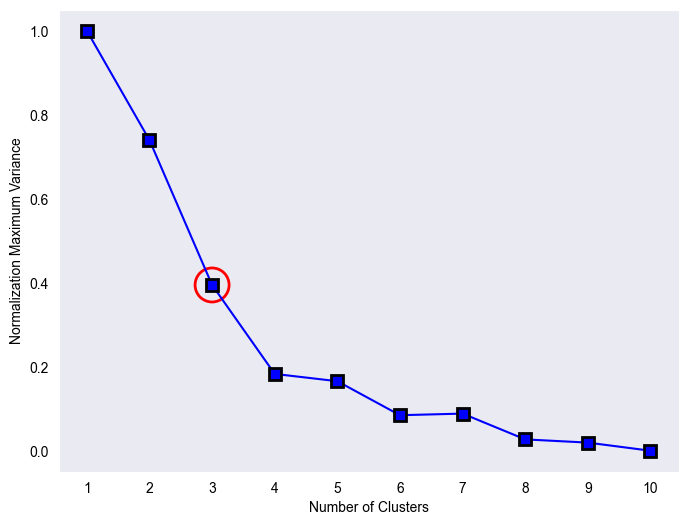

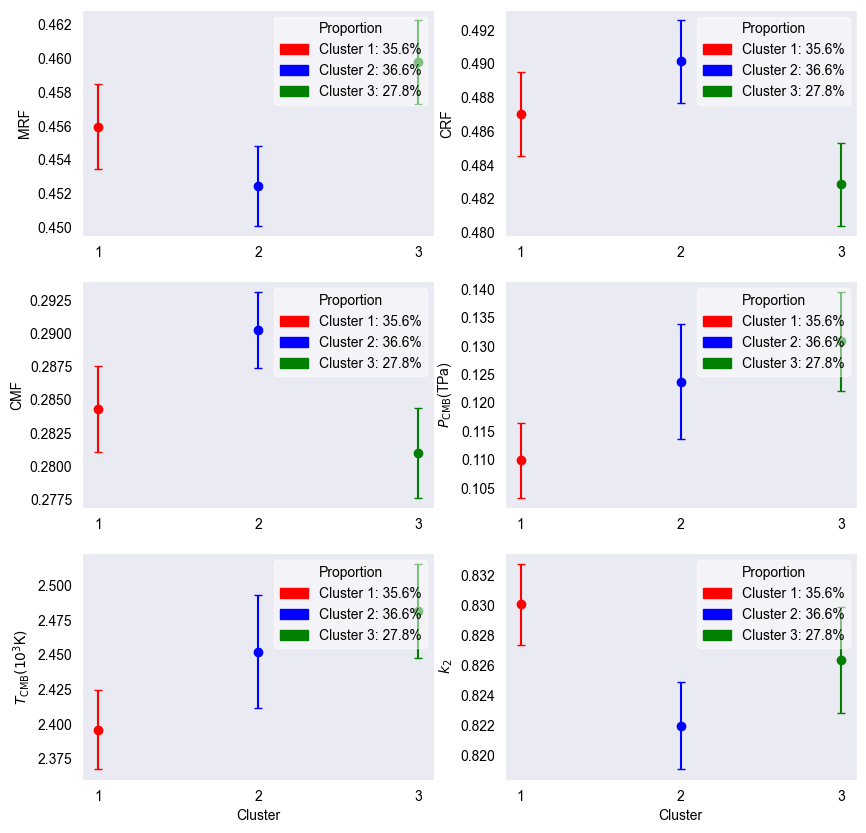

In [5]:
generator = PlanetsDataGenerator(size=sample_num)
planet_names = ['Kepler78b', 'Earth']
planet_solutions = {}

for p in planet_names:
    planet_x = eval('generator.{}()'.format(p))
    planet_x = cvae_m_x_50th.transform(planet_x)
    
    # Prediction
    pred = cvae_model.pred_distribution_inference(planet_x, TIMES, DEVICE)
    
    # Calculate mean of each input
    mean_pred = get_pred_mean(pred[-1], sample_num)
    
    mean_pred_inverse = cvae_m_y_50th.inverse_transform(mean_pred)
    mean_pred_inverse[:, 5] = mean_pred_inverse[:, 5] / 1000
    mean_pred_inverse[:, 6] = mean_pred_inverse[:, 6] / 1000
    mean_pred_inverse = mean_pred_inverse[:, [1, 2, 4, 5, 6, 7]]
    
    stand_scaler = StandardScaler()
    mean_pred_standard = stand_scaler.fit_transform(mean_pred_inverse)
    elbow = get_elbow(mean_pred_standard)
    
    kmeans = KMeans(random_state=0, n_clusters=elbow)
    result = kmeans.fit(mean_pred_standard)
    labels_ = result.labels_ + 1
    m_s_dict = get_mean_std(x_labels, labels_, mean_pred_inverse)
    # get_error_bar(output_parameters, labels_, m_s_dict)
    
    # get_error_bar(x_labels, labels_, m_s_dict, ncols=2, nrows=3, save_path=cluster_error_bar_save_path, planet_name=p)
    get_error_bar(x_labels, labels_, m_s_dict, ncols=2, nrows=3, planet_name=p)
    
    planet_solutions[p] = {
    "mean_prediction": mean_pred_inverse.tolist(),
    "labels": labels_.tolist()
    }

# with open(os.path.join(cluster_error_bar_save_path, 'planet_solutions.json'), 'w', encoding='utf-8') as f:
#     json.dump(planet_solutions, f, ensure_ascii=False, indent=4)

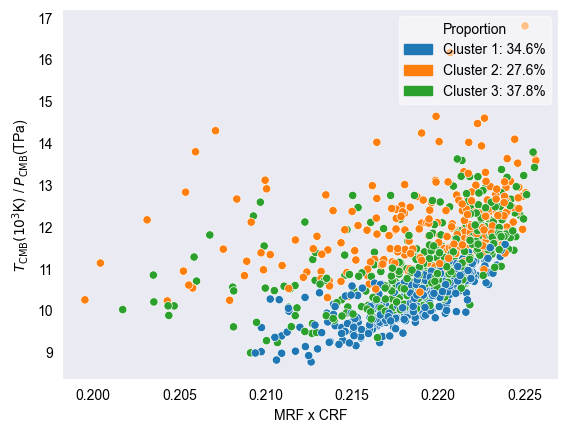

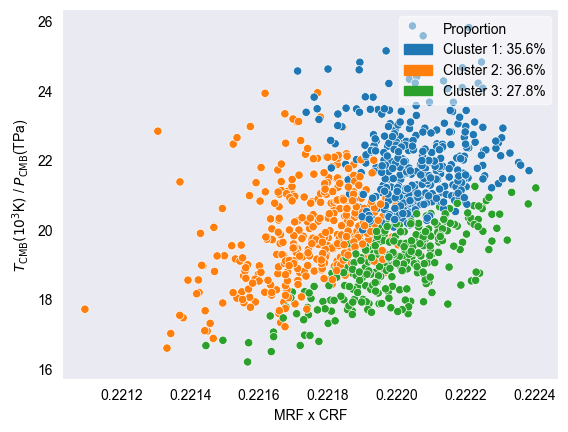

In [6]:
for p in planet_names:
    mean_pred_inverse = np.array(planet_solutions[p]['mean_prediction'])
    labels_ = np.array(planet_solutions[p]['labels'])
    
    x_axis = mean_pred_inverse[:, 0] * mean_pred_inverse[:, 1]
    y_axis = mean_pred_inverse[:, 4] / mean_pred_inverse[:, 3]
    
    unique_label, counts = np.unique(labels_, return_counts=True)
    
    counts = counts / np.sum(counts) * 100
    hue_levels = sorted(unique_label)
    palette = sns.color_palette(n_colors=len(hue_levels))
    
    cat_palette_dict = dict(zip(unique_label, palette))
    
    handles = []
    for idx, l in enumerate(unique_label):
        label_text = f"Cluster {int(l)}: {counts[idx]:.1f}%"
        patch = mpatches.Patch(color=cat_palette_dict[l], label=label_text)
        handles.append(patch)
    
    fig = plt.figure()
    sns.scatterplot(x=x_axis, y=y_axis, hue=labels_, palette=cat_palette_dict, legend=False)
    plt.xlabel("MRF x CRF")
    plt.ylabel("$T_{\mathrm{CMB}}(10^{3}$K$)$ / $P_{\mathrm{CMB}}$(TPa)")
    plt.legend(handles=handles, title='Proportion', loc='upper right', framealpha=0.5)
    plt.show()
    # fig.savefig(os.path.join(cluster_error_bar_save_path, 'scatterplot_{}.pdf'.format(p)), dpi=300)